### Data to use
The data was shared throgth 
https://gdex.ucar.edu/datasets/d010077/dataaccess/

#### THREDDS Data Service
https://tds.gdex.ucar.edu/thredds/catalog/files/d010077/native_diag/catalog.html

In [1]:
from mpasviewer import scvtmesh
import cartopy.crs as ccrs
from datetime import datetime

In [2]:
url_thredds = "https://tds.gdex.ucar.edu/thredds/catalog/files/d010077/native_diag/catalog.html" ### MAAG
inidt = datetime(2017, 9, 15, 6); enddt = datetime(2017, 9, 15, 10) ## MAAG
list_files = scvtmesh.get_thredds_list(url_thredds, date_start=inidt, date_end=enddt)

In [3]:
# list_files

In [4]:
mpasd = scvtmesh(grid_file = "https://tds.gdex.ucar.edu/thredds/dodsC/files/d010077/native_diag/MAAG.static.nc",
                 diag_list = list_files)

In [5]:
# mpasd.dataset()
mpasd.dataset(load_variables=['rainnc', 'rainc', "u10","v10","t2m",'olrtoa','refl10cm_max',])

Loaded grid_file dataset: https://tds.gdex.ucar.edu/thredds/dodsC/files/d010077/native_diag/MAAG.static.nc


In [6]:
mpasd.rain_rate()

In [7]:
dta = mpasd.load()

In [8]:
subd = mpasd.get_subset(dta, lon = (-72.56,-59.17), lat = (12.16,23.49))
# subd

In [9]:
from earthcmap import escmap

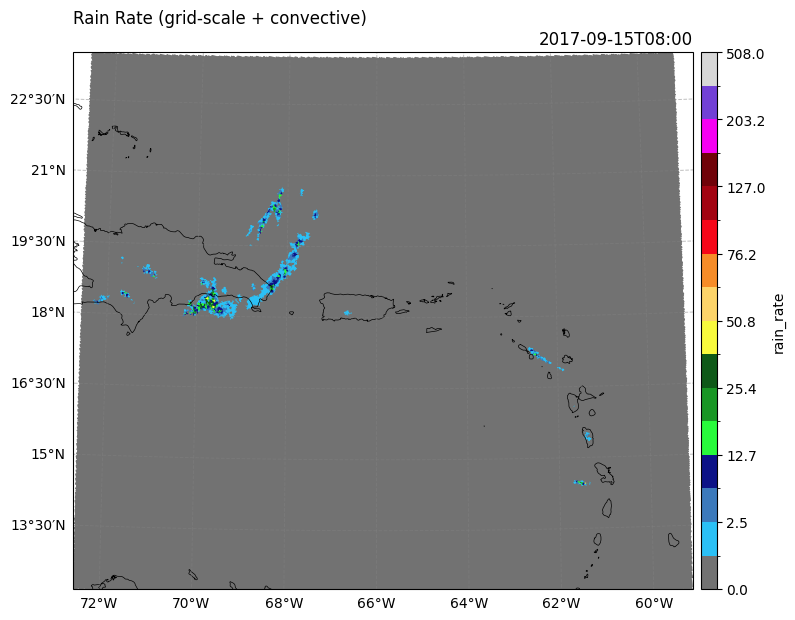

In [10]:
cmap, norm = escmap("nwps_qpe", units="mm")

mpasd.show(subd,var_name='rain_rate', time_index=2, figsize=(8,8), cmap = cmap, norm = norm,)

In [11]:
from ipywidgets import interact, Dropdown, SelectionSlider
from IPython.display import display, clear_output

In [12]:
mpas_vars = ['rainnc', 'rainc', "u10","v10","t2m",'olrtoa','refl10cm_max',]
times = sorted([str(x) for x in dta['time'].data.astype('datetime64[s]')])
num_steps = len(times)

In [16]:
def update_plot(variable, time_step):
    mpasd.show(subd, var_name = variable, time_index = time_step, figsize=(9,9))
    
# dropdown and slider widgets
variable_dropdown = Dropdown(options=mpas_vars, description='Variable:')
time_slider = SelectionSlider(
    options=times,
    value=times[1],
    description='Datetime:',
    layout={'width': '500px'},
    style={'description_width': 'initial'}
)

In [17]:
interact(update_plot, variable=variable_dropdown, time_step=time_slider)

interactive(children=(Dropdown(description='Variable:', options=('rainnc', 'rainc', 'u10', 'v10', 't2m', 'olrt…

<function __main__.update_plot(variable, time_step)>